In [1]:
# ── Erste Zelle im Notebook ──
import time
notebook_start = time.time()
print("Notebook gestartet.")

Notebook gestartet.


In [2]:
# ==============================================================
# PHASE 1: InceptionV3 kennenlernen – Architektur & Inferenz
# ==============================================================

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import random

# Seeds ganz am Anfang setzen
SEED=42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# ── 1.1 Vollständiges InceptionV3-Modell laden ────────────────
#
# Wichtig: InceptionV3 erwartet 299×299 Pixel – größer als VGG19 (224×224).
# Das liegt an den tieferen Inception-Modulen, die größere Feature-Maps brauchen.
#
model_full = tf.keras.applications.InceptionV3(
    weights="imagenet",
    include_top=True
)
model_full.summary()
# ▶ Beobachten:
#   - Inception-Module: parallele Conv-Pfade (1×1, 3×3, 5×5) werden zusammengeführt
#   - Letzter Layer: Dense(1000, softmax) → 1000 ImageNet-Klassen
#   - Gesamtparameter: ~23,9 Mio. (zum Vergleich: VGG19 hat ~143,7 Mio.!)

96112376/96112376 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "inception_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 149, 149,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 149, 149,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 147, 147,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 147, 147,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 73, 73,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 73, 73,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 71, 71,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 23,851,784 (90.99 MB)

 Trainable params: 23,817,352 (90.86 MB)

 Non-trainable params: 34,432 (134.50 KB)

Mounted at /content/drive


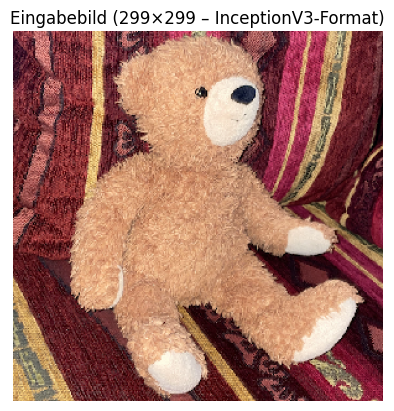

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Top-5-Vorhersagen des vortrainierten InceptionV3:
  teddy                         : 89.16%
  toyshop                       : 0.45%
  crib                          : 0.42%
  wool                          : 0.36%
  rocking_chair                 : 0.33%


In [3]:
# ── 1.2 Bild laden und klassifizieren ─────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os
base_dir = "/content/drive/MyDrive/Colab Notebooks/DHBW Sommersemester 2026/Data"

file = os.path.join(base_dir, "teddy.png")  # Gleiche Aufgabe wie VGG19-Notebook

# InceptionV3 benötigt zwingend 299×299 (≠ VGG19 mit 224×224)
img = tf.keras.utils.load_img(file, target_size=(299, 299))
img_array = tf.keras.utils.img_to_array(img)

plt.imshow(img_array.astype("uint8"))
plt.title("Eingabebild (299×299 – InceptionV3-Format)")
plt.axis("off")
plt.show()

# Vorverarbeitung: InceptionV3 normiert auf [-1, 1] – anders als VGG19!
img_preprocessed = tf.keras.applications.inception_v3.preprocess_input(img_array)
pred = model_full.predict(img_preprocessed.reshape(1, 299, 299, 3))

top5 = tf.keras.applications.inception_v3.decode_predictions(pred, top=5)
print("Top-5-Vorhersagen des vortrainierten InceptionV3:")
for _, name, prob in top5[0]:
    print(f"  {name:30s}: {prob*100:.2f}%")

In [4]:
# ==============================================================
# PHASE 2: Transfer Learning mit InceptionV3
# ==============================================================

# ── 2.1 InceptionV3 OHNE Klassifikationskopf laden ───────────
#
# Gleiche Strategie wie bei VGG19 – aber andere Architektur:
#
#   VGG19:       Sequenziell – Conv → Conv → Pool → Conv → ... → Dense
#   InceptionV3: Parallel   – in jedem Inception-Modul laufen mehrere
#                             Faltungsgrößen gleichzeitig und werden
#                             anschließend zusammengeführt (Concatenate)
#
base_model = tf.keras.applications.InceptionV3(
    weights="imagenet",
    include_top=False,      # Klassifikationskopf entfernen
    input_shape=(299, 299, 3)
)
base_model.summary()
# ▶ Beobachten: Ausgabe ist jetzt ein Feature-Map-Tensor, kein Klassen-Vektor

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "inception_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_94 (Conv2D)  │ (None, 149, 149,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 149, 149,  │         96 │ conv2d_94[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_94       │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, 147, 147,  │      9,216 │ activation_94[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_95[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_95       │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_96 (Conv2D)  │ (None, 147, 147,  │     18,432 │ activation_95[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_96[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_96       │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 73, 73,    │          0 │ activation_96[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_97 (Conv2D)  │ (None, 73, 73,    │      5,120 │ max_pooling2d_4[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_97[0][0]   │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_97       │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_98 (Conv2D)  │ (None, 71, 71,    │    138,240 │ activation_97[0]… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_98[0][0]   │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_98       │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 21,802,784 (83.17 MB)

 Trainable params: 21,768,352 (83.04 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [5]:
# ── 2.2 Gewichte einfrieren ───────────────────────────────────
#
# Gleiche Begründung wie bei VGG19:
# InceptionV3 wurde auf 1,2 Mio. Bildern trainiert – dieses Wissen behalten wir.
# Catastrophic Forgetting verhindern → alle Basis-Gewichte einfrieren.
#
for layer in base_model.layers:
    layer.trainable = False

print(f"Eingefrorene Layer: {len(base_model.layers)}")
print(f"Trainierbare Gewichte im Basis-Modell: {len(base_model.trainable_weights)}")
# → Erwartet: 0 trainierbare Gewichte in der Basis

Eingefrorene Layer: 311
Trainierbare Gewichte im Basis-Modell: 0


In [6]:
# ── 2.3 Eigenen Klassifikationskopf hinzufügen ────────────────
#
# Gleiche Struktur wie beim VGG19-Notebook → direkter Vergleich möglich:
#
#   GlobalAveragePooling2D → reduziert Feature-Maps auf einen Vektor
#   Dense(128, relu)       → aufgabenspezifische Merkmalskombination
#   Dense(1, sigmoid)      → Binärklassifikation: Teddybär ja/nein
#
inputs  = tf.keras.Input(shape=(299, 299, 3))
x       = base_model(inputs, training=False)
x       = tf.keras.layers.GlobalAveragePooling2D()(x)
x       = tf.keras.layers.Dense(128, activation="relu")(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model_tl = tf.keras.Model(inputs, outputs)
model_tl.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,065,185 (84.17 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [7]:
# ── 2.4 Parametervergleich InceptionV3 vs. VGG19 ─────────────
#
# Leitfrage: Welche Architektur ist effizienter?
#
total     = model_tl.count_params()
trainable = sum(tf.size(w).numpy() for w in model_tl.trainable_weights)
frozen    = total - trainable

print("── InceptionV3 Transfer Learning ──────────────────")
print(f"  Gesamt-Parameter:          {total:>12,}")
print(f"  Trainierbare Parameter:    {trainable:>12,}  ({trainable/total*100:.2f}%)")
print(f"  Eingefrorene Parameter:    {frozen:>12,}  ({frozen/total*100:.2f}%)")
print()
print("── Zum Vergleich: VGG19 (aus vorheriger Vorlesung) ─")
print(f"  Gesamt-Parameter:          ~143.667.240")
print(f"  InceptionV3 ist ca. {143_667_240 // total}× kompakter als VGG19")

# ▶ Erwartet:
#   InceptionV3 Gesamt: ~21,8 Mio. Parameter
#   VGG19       Gesamt: ~143,7 Mio. Parameter
#   → InceptionV3 hat ~6× weniger Parameter bei oft besserer Genauigkeit!

── InceptionV3 Transfer Learning ──────────────────
  Gesamt-Parameter:            22,065,185
  Trainierbare Parameter:         262,401  (1.19%)
  Eingefrorene Parameter:      21,802,784  (98.81%)

── Zum Vergleich: VGG19 (aus vorheriger Vorlesung) ─
  Gesamt-Parameter:          ~143.667.240
  InceptionV3 ist ca. 6× kompakter als VGG19


In [8]:
# ── 2.5 Laufzeitmessung (Leitfrage 1) ────────────────────────
import time

model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Dummy-Daten für Laufzeittest (kein echter Datensatz erforderlich)
dummy_x = np.random.rand(16, 299, 299, 3).astype("float32")
dummy_y = np.random.randint(0, 2, size=(16,)).astype("float32")

start = time.time()
model_tl.fit(dummy_x, dummy_y, epochs=1, verbose=0)
elapsed = time.time() - start

print(f"InceptionV3 – 1 Epoch (16 Bilder): {elapsed:.2f} Sekunden")
print()
print("Hinweis: In der Praxis VGG19 mit gleichem Setup vergleichen.")
print("InceptionV3 ist trotz ähnlicher Eingabegröße (299×299) oft schneller,")
print("da deutlich weniger Parameter trainiert werden.")

InceptionV3 – 1 Epoch (16 Bilder): 13.19 Sekunden

Hinweis: In der Praxis VGG19 mit gleichem Setup vergleichen.
InceptionV3 ist trotz ähnlicher Eingabegröße (299×299) oft schneller,
da deutlich weniger Parameter trainiert werden.


In [9]:
# ==============================================================
# VERGLEICHSTABELLE: VGG19 vs. InceptionV3
# ==============================================================

vergleich = {
    "Kriterium":             ["Architektur",       "Eingabegröße", "Gesamt-Parameter",
                              "TL-trainierb. Par.", "Vorverarbeitung",   "Stärke"],
    "VGG19":                 ["Linear (sequenziell)", "224 × 224",  "~143,7 Mio.",
                              "~65.000 (<1%)",      "BGR-Shift",        "Einfach, gut dokumentiert"],
    "InceptionV3":           ["Parallel (Inception-Module)", "299 × 299", "~21,8 Mio.",
                              "~65.000 (<1%)",      "Normierung [-1,1]", "Kompakt, oft genauer"],
}

import pandas as pd
df = pd.DataFrame(vergleich)
print(df.to_string(index=False))

         Kriterium                     VGG19                 InceptionV3
       Architektur      Linear (sequenziell) Parallel (Inception-Module)
      Eingabegröße                 224 × 224                   299 × 299
  Gesamt-Parameter               ~143,7 Mio.                  ~21,8 Mio.
TL-trainierb. Par.             ~65.000 (<1%)               ~65.000 (<1%)
   Vorverarbeitung                 BGR-Shift           Normierung [-1,1]
            Stärke Einfach, gut dokumentiert        Kompakt, oft genauer


In [10]:
# ── Letzte Zelle im Notebook ──
total = time.time() - notebook_start
minuten = int(total // 60)
sekunden = int(total % 60)
print(f"Gesamtlaufzeit: {minuten} min {sekunden} sek")

Gesamtlaufzeit: 1 min 0 sek
